In [ ]:
import numpy as np 
import os
import sys
from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
sns.set_theme()

# import fastkml
from shapely import Polygon, box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data, get_aorc_layers
from validation import validate_date_pairs, validate_date

ImportError: cannot import name 'assemble_enviro_data' from 'layers' (/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py)

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
data_dir = '../data/'

mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


In [5]:
aoi = box(*mcs_aoi.total_bounds)
dates = [("20200101", "20200113"), 
         ("20200101", "20200129"),
         ("20200113", "20200129"),
         ("20210202", "20210214")]
dates_val = validate_date_pairs(dates)
fp_out = data_dir + 'stacks/mores_creek'

In [4]:
# years = {2021}
# s3_out = s3fs.S3FileSystem(anon=True)
# # print(years)
# fileset = [s3fs.S3Map(
#                 root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
#             ) for yr in years]
# print(fileset)
# ds_2021 = xr.open_mfdataset(fileset, engine='zarr')
# print(ds_2021)

In [5]:
# merged = xr.concat([ds_2020, ds_2021], dim='time')
# merged

In [6]:
# clipped = merged.rio.clip(mcs_aoi.geometry.values, crs='EPSG:4326')
# plt.plot(clipped['time'], clipped['APCP_surface'].max(dim=['latitude', 'longitude']))

In [7]:
import pandas as pd
import xarray as xr

def report_time_gaps(ds, expected_freq='1h'):
    """
    Checks for missing timestamps in an xarray Dataset along the 'time' dimension.
    
    Parameters:
    ds (xr.Dataset): The dataset to check.
    expected_freq (str): The expected frequency (e.g., '1h' for hourly).
    """
    if 'time' not in ds.coords:
        print("Error: 'time' dimension not found in dataset.")
        return

    # Get the actual times from the dataset
    actual_times = pd.DatetimeIndex(ds.time.values)
    
    # Create the ideal timeline from the first to the last available timestamp
    ideal_times = pd.date_range(start=actual_times.min(), 
                                end=actual_times.max(), 
                                freq=expected_freq)
    
    # Find the difference
    missing_times = ideal_times.difference(actual_times)
    
    total_expected = len(ideal_times)
    total_missing = len(missing_times)
    
    print(f"--- Time Dimension Report ---")
    print(f"Expected Frequency: {expected_freq}")
    print(f"Start: {actual_times.min()}")
    print(f"End:   {actual_times.max()}")
    print(f"Total expected steps: {total_expected}")
    print(f"Missing steps: {total_missing}")
    
    if total_missing > 0:
        print(f"\nFirst 10 missing timestamps:")
        for t in missing_times[:10]:
            print(f"  - {t}")
        
        # Check for non-monotonicity (which caused your initial error)
        if not actual_times.is_monotonic_increasing:
            print("\nWARNING: Time index is NOT monotonically increasing!")
    else:
        print("\nSuccess: No missing time chunks detected.")

    return missing_times

def fix_aorc_dates(ds):
    # Filter out any dates from 1970 or any year that doesn't match the file
    # This keeps only the 'good' data
        return ds.sel(time=ds.time.dt.year > 1970)

In [8]:
# clipped['time'].values.min()

# # get 5 time values before and after the min
# min_time = clipped['time'].values.min()
# time_values = clipped['time'].values
# before_after_indices = []
# for i, t in enumerate(time_values):
#     if t == min_time:
#         before_after_indices.extend(range(max(0, i-5), min(len(time_values), i+6)))
#         break

# before_after_times = time_values[before_after_indices]
# before_after_times


In [9]:
# fix_aorc_dates(clipped)
# report_time_gaps(fix_aorc_dates(clipped), expected_freq='1h')

In [10]:
# aorc = get_aorc_layers(aoi=mcs_aoi, 
#                        date_pairs=validate_date_pairs(dates), 
#                        crs='EPSG:4326', 
#                        ref_grid=None)

In [ ]:
data = assemble_data(aoi,
                    dates,
                    fp_out)
data

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


Got NLCD: <class 'xarray.core.dataset.Dataset'>
Got DEM: <class 'xarray.core.dataarray.DataArray'>
Got topo layers: <class 'xarray.core.dataset.Dataset'>
Got snow climatology: <class 'xarray.core.dataset.Dataset'>


QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 465.01it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  2.58it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 64280.52it/s]
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:402: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_days = ds.dims['Day']
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:402: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_days = ds.dims['Day']
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:402: FutureWarning: The return type of `Dataset.dims` wil

<xarray.Dataset> Size: 30kB
Dimensions:      (x: 26, y: 20, pair: 4)
Coordinates:
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
  * pair         (pair) <U17 272B '20200101_20200113' ... '20210202_20210214'
    spatial_ref  int64 8B 0
    band         int64 8B 1
    crs          int64 8B 0
Data variables:
    cover_2019   (y, x) uint8 520B 52 52 71 71 52 42 42 ... 42 52 42 42 52 52 52
    canopy_2019  (y, x) float32 2kB 0.0 0.0 0.0 11.0 14.0 ... 69.0 12.0 19.0 0.0
    elevation    (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope        (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect       (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    curve        (y, x) float32 2kB -0.0 -0.0 0.06983 ... -0.0 -0.0128 -0.0
    snow_class   (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5.0
    swe_change   (pair, y, x) float32 8kB 0.1942 0.1578 0.1578 ... 0.0478 0.0952
    sd_change    (pair, y, x) float32 8kB 0.8258 0.781 0.781 ... 0.2504 0.4676
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0

In [12]:
print(data)

<xarray.Dataset> Size: 30kB
Dimensions:      (x: 26, y: 20, pair: 4)
Coordinates:
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
  * pair         (pair) <U17 272B '20200101_20200113' ... '20210202_20210214'
    spatial_ref  int64 8B 0
    band         int64 8B 1
    crs          int64 8B 0
Data variables:
    cover_2019   (y, x) uint8 520B 52 52 71 71 52 42 42 ... 42 52 42 42 52 52 52
    canopy_2019  (y, x) float32 2kB 0.0 0.0 0.0 11.0 14.0 ... 69.0 12.0 19.0 0.0
    elevation    (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope        (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect       (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    curve        (y, x) float32 2kB -0.0 -0.0 0.06983 ... -0.0 -0.0128 -0.0
    snow_class   (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5.0
    swe_change   (pair, y, x) 

/var/folders/vr/54bwt92x0tq5_lsckcv161380000gp/T/ipykernel_11009/1108996813.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


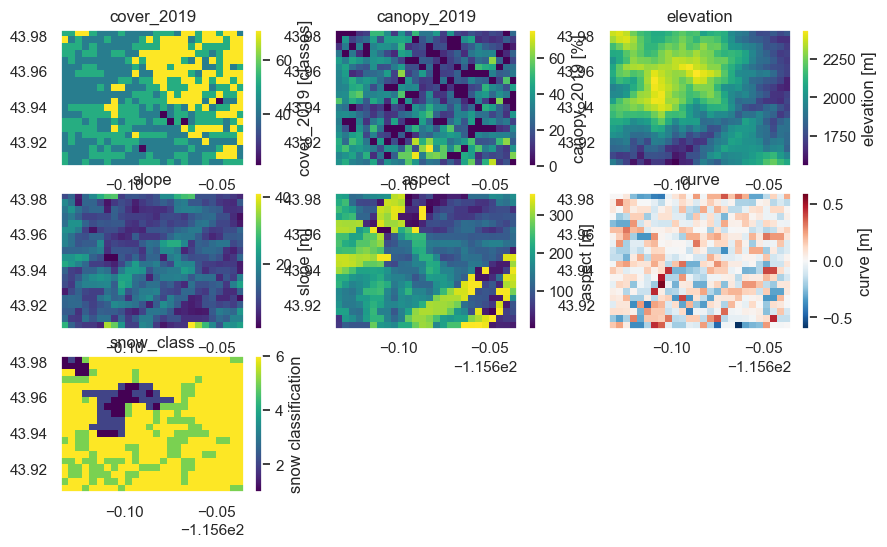

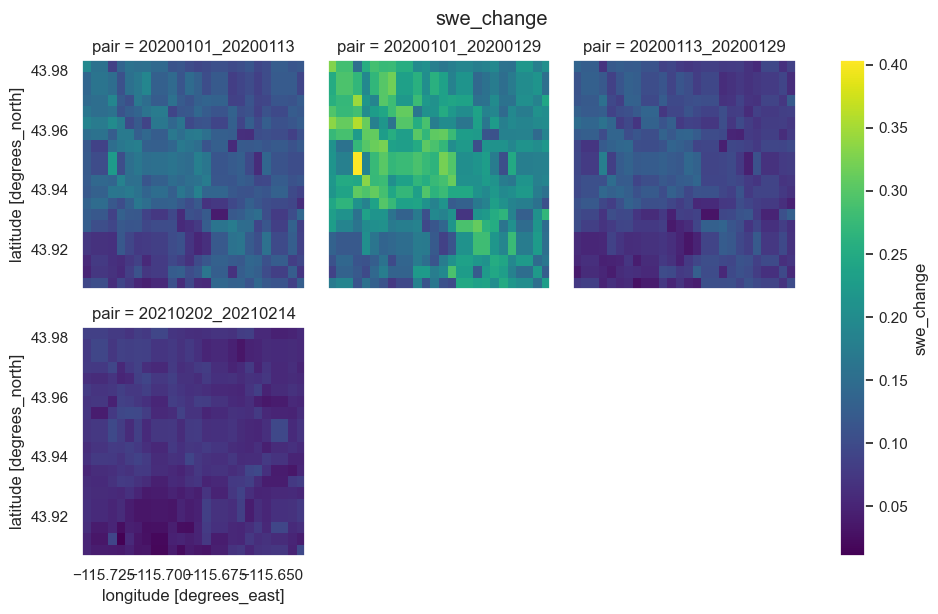

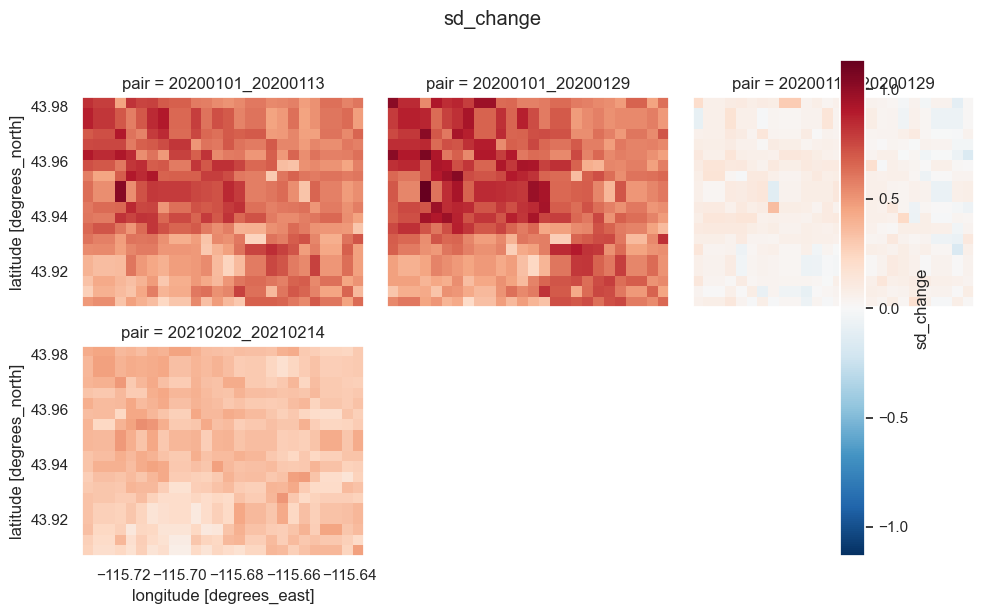

In [13]:
n = len(data)
fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize = (10, 6))
axes = axes.flatten()

for i, var in enumerate(data.data_vars): 
    # print(var, i)
    # print(data[var])
    data[var].plot(ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    if 'pair' in data[var].dims:
        axes[i].set_visible(False)  # hide the placeholder axis in the main grid
        data[var].plot(
            col='pair',
            col_wrap=3,
            figsize=(10, 3 * int(np.ceil(data.sizes['pair'] / 3)))
        )
        plt.suptitle(var, y=1.02)
        # plt.tight_layout()
        # plt.show()
    # break

plt.tight_layout()
plt.show()

In [14]:
import earthaccess
def get_snow_layers(
    aoi, 
    crs,
    date_pairs,
    ref_grid = None
):
    print(aoi)
    # turn aoi into list of points in counter-clockwise order 
    xx, yy = aoi.exterior.coords.xy
    x = xx.tolist()
    y = yy.tolist()

    g = gpd.GeoSeries([aoi], crs=crs)

    print(type(x), type(y))
    print(list(zip(x,y)))

    years = get_years(date_pairs)

    print(str(min(years)), str(max(years)))

    grans = earthaccess.search_data(
        short_name='WUS_UCLA_SR', 
        cloud_hosted=True, 
        temporal=(str(min(years)), str(max(years))),
        polygon=list(zip(x,y))
    )

    auth = earthaccess.login()
    if not auth.authenticated:
        # ask for credentials and persist them in a .netrc file
        auth.login(strategy="interactive", persist=True)

    # print(grans)
    fileset = earthaccess.open(grans)
    # ds = xr.open_mfdataset(fileset, chunks={})
    # Separate granules by type based on naming convention [cite: 42, 44]
    swe_files = [f for f in fileset if "SWE_SCA_POST" in (f.path if hasattr(f, 'path') else str(f))]
    sd_files = [f for f in fileset if "SD_POST" in (f.path if hasattr(f, 'path') else str(f))]

    # Process and concatenate each group along time
    ds_swe = xr.concat([process_ucla_granule(f) for f in swe_files], dim='time').sortby('time')
    ds_sd = xr.concat([process_ucla_granule(f) for f in sd_files], dim='time').sortby('time')

    # Merge the different parameters into one large data cube
    # This combines SWE_Post, SCA_Post, and SD_Post [cite: 20, 32]
    ds_full = xr.merge([ds_swe, ds_sd])
    ds_full = ds_full.rio.write_crs("EPSG:4326")
    ds_full = ds_full.isel(Stats=2)
    ds_clip = ds_full.rio.clip(g, crs=crs)

    print(ds_clip)

    ds = xr.Dataset()
    ds_list = []
    # get metrics for each date pair
    for i, (start_date, end_date) in enumerate(date_pairs):
        ds_slice = ds_clip.sel(time=slice(start_date, end_date))

        # ran into some missing data (e.g. 2021/02-2021/11)
        if (len(ds_slice['time']) == 0): 
            print(f'Could not get AORC data for {start_date} to {end_date}.')
            continue

        ds_metrics = get_snow_metrics(ds_slice)
        pair_name = start_date.strftime('%Y%m%d') + "_" + end_date.strftime('%Y%m%d')
        ds_metrics['pair'] = pair_name

        ds_list.append(ds_metrics)

        # reproject to reference grid 
        if ref_grid is not None : 
            ds_metrics = ds_metrics.rio.reproject_match(ref_grid)

    ds = xr.concat(ds_list, dim='pair')
    return ds
    # print(ds)


def get_snow_metrics(
    ds,
    metrics = 'all'
) -> xr.Dataset:
    
    out = xr.Dataset()

    valid_metrics = [
        'total_swe',
        'max_swe'
    ]

    if metrics == 'all':
        metrics = valid_metrics
    else:
        for metric in metrics:
            if metric not in valid_metrics:
                raise ValueError(f"Invalid metric: {metric}. Valid metrics are: {valid_metrics}")

    if 'total_swe' in metrics: 
        out['total_swe'] = ds['SWE_Post'].sum(dim='time')
    if 'max_swe' in metrics: 
        out['max_swe'] = ds['SWE_Post'].max(dim='time')
    # if 'snow_cover_change' in metrics: 
    #     out['snow_cover_change'] = ds['SCA_Post']

    return out

import xarray as xr
import pandas as pd
import re

def process_ucla_granule(file_obj):
    # Open the dataset
    ds = xr.open_dataset(file_obj, chunks={})
    # print(f"Processing file: {file_obj}")
    # print(ds)
    
    # 1. Parse the Water Year (WY) for the time axis [cite: 30, 42]
    filename = file_obj.path if hasattr(file_obj, 'path') else str(file_obj)
    match = re.search(r'WY(\d{4})_\d{2}', filename)
    start_year = int(match.group(1))
    
    # 2. Create time coordinate starting Oct 1st [cite: 30, 101]
    num_days = ds.dims['Day']
    time_coords = pd.date_range(start=f"{start_year}-10-01", periods=num_days, freq='D')
    
    # 3. Handle Spatial Coordinates [cite: 37, 39]
    # Squeeze (225x1) to 1D and rename to y (lat) and x (lon)
    lat_values = ds.Latitude.values.flatten()
    lon_values = ds.Longitude.values.flatten()
    
    # Drop old lat/lon to avoid conflicts during renaming
    # ds = ds.drop_vars(['Latitude', 'Longitude'])
    
    # Rename 'day' to 'time' and map statistics dimension if necessary [cite: 28]
    ds = ds.rename({'Day': 'time', 'Latitude': 'y', 'Longitude': 'x'})
    
    # Assign the new dimensional coordinates
    ds = ds.assign_coords(
        time=time_coords,
        y=lat_values,
        x=lon_values
    )
    
    return ds

def get_years(
    date_pairs
): 
    years = set()
    for start_date, end_date in date_pairs:
        years.update([start_date.year, end_date.year])
    return years

In [15]:
# snow = get_snow_layers(aoi=aoi, crs='EPSG:4326', date_pairs=dates_val, ref_grid=None)

In [16]:
# snow

In [17]:
# fig, axes = plt.subplots(1, len(snow['pair']), figsize = (15, 5))
# for a, p in zip(axes, snow['pair']):
#     snow.sel(pair=p)['total_swe'].plot(ax=a)

# plt.tight_layout()
# plt.show()

In [113]:
import asf_search as asf
import json
def assemble_uavsar_data(
    flight_name,
    flight_paths
):
    res = asf.search(platform= 'UAVSAR', 
                     campaign = 'Lowman, CO', 
                     beamMode='POL')[1].properties
    print(json.dumps(res, indent=2))
    return res

wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_01_BU.dop
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_01_BU_s2_2x8.llh
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_01_BU_s2_2x8.lkv
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_20002_006_200131_L090VV_01_BU_s2_2x8.slc
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_20002_006_200131_L090VV_01_BU.ann
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_20007_002_200213_L090VV_01_BU_s2_2x8.slc
    wget https://downloaduav2.jpl.nasa.gov/Release30/lowman_05208_01/lowman_05208_20007_002_200213_L090VV_01_BU.ann

In [114]:
res = assemble_uavsar_data('Lowman, CO', None)

{
  "centerLat": 44.0327840342307,
  "centerLon": -115.586431683309,
  "stopTime": "2021-03-22T16:58:27Z",
  "fileID": "UA_lowman_05208_21021_007_210322_L090_CX_01-SLOPE",
  "flightDirection": null,
  "pathNumber": 5208,
  "processingLevel": "SLOPE",
  "url": "https://datapool.asf.alaska.edu/SLOPE/UA/lowman_05208_21021_007_210322_L090_CX_01.slope",
  "startTime": "2021-03-22T16:58:27Z",
  "sceneName": "UA_lowman_05208_21021_007_210322_L090_CX_01",
  "browse": [
    "https://datapool.asf.alaska.edu/BROWSE/UA/lowman_05208_21021_007_210322_L090_CX_01.gif"
  ],
  "platform": "UAVSAR",
  "bytes": 3506884800,
  "md5sum": "75eb7b7860d5444ec9230c07b71c87a1",
  "frameNumber": 881,
  "granuleType": "UAVSAR_POLSAR_SCENE",
  "orbit": -1,
  "polarization": "Full",
  "processingDate": "2021-04-07T01:29:45Z",
  "sensor": "UAVSAR",
  "groupID": "UA_lowman_05208_21021_007_210322_L090_CX_01",
  "insarStackId": "-1",
  "fileName": "lowman_05208_21021_007_210322_L090_CX_01.slope",
  "beamModeType": "POL"


In [ ]:
import asf_search as asf
from collections import defaultdict
def get_uavsar_links(
    flight_name, 
    flight_num = None,
    getann = False, 
    start_date = '2020-01-01',
    end_date = '2021-12-31',
    pol = ['HH'],
    sec = ['s1', 's2', 's3'],
    pxspc = '2x8',
    tag = ['BU']
): 
    jpl_site = 'https://downloaduav2.jpl.nasa.gov'
    release_folder = 'Release30'
    
    links = defaultdict(list)

    # start_date = validate_date(start_date)
    # end_date = validate_date(end_date)
    # print(start_date, end_date)

    # for t in tag:   
    campaigns = {
        'grmesa': 'Grand Mesa, CO',
        'lowman': 'Lowman, CO',
        'fraser': 'Fraser, CO',
        'ironto': 'Ironton, CO',                    # Senator Beck Basin
        'peeler': 'Peeler Peak, CO',                # East River
        'rockmt': 'Rocky Mountains NP, CO',         # Cameron Pass
        'silver': 'Silver City, ID',                # Reynolds Creek
        'uticam': 'Utica, MT',                      # Central Ag Research Center
        'saltla': 'Salt Lake City, UT',             # Little Cottonwood Canyon
        'losala': 'Los Alamos, NM',                 # Jemez River
        'dorado': 'Eldorado National Forest, CA',   # American River Basin
        'donner': 'Donner Memorial State Park, CA', # Sagehen Creek
        'sierra': 'Sierra National Forest, CA'      # Lakes Basin
    }

    if flight_name not in campaigns.values():
        # print(f'{flight_name} not found')
        try: 
            flight_abbr = flight_name 
            flight_name = campaigns[flight_name]
            # print(flight_name)
        except KeyError:
            raise ValueError(f"Invalid flight name: {flight_name}."\
                             f" Valid options are: {campaigns}")
    else: 
        flight_abbr = next((k for k, v in campaigns.items() if v == flight_name), None)
    print(f'Getting files for {flight_name} ({flight_abbr}).')

    if flight_num is None: 
        grans = asf.search(platform= 'UAVSAR', 
                        campaign = flight_name, 
                        beamMode='POL',
                        #    polarization=pol,
                        start=start_date,
                        end=end_date)
    else: 
        grans = asf.search(platform= 'UAVSAR', 
                           campaign = flight_name, 
                           flightLine=flight_num,
                           beamMode='POL',
                           start=start_date,
                           end=end_date)
    
    print(len(grans), "granules found for", flight_name)
    
    # get all flight numbers from grans
    # nums = set([g.properties['pathNumber'] for g in grans])

    flight_lines = set()

    for g in grans: 
        # props = g.properties
        # start = validate_date(props['start_date'])
        # end = validate_date(props['end_date'])

        # num = props['pathNumber']

        # folder = f'{flight_name}_{num}_01'

        # generate_jpl_urls_from_asf(g.properties)
        # UA_lowman_05208_21021_007_210322_L090_CX_01
        scene_name = g.properties["sceneName"]
        parts = scene_name.split("_")
        
        # Extract components from ASF sceneName (e.g., UA_lowman_05208_21019-019_...)
        site = parts[1]
        flight_line = parts[2].zfill(5)
        flight_lines.add(flight_line)
        # flight1_id = parts[3].replace("-", "_")  # Convert 21019-019 to 21019_019
        # flight2_id = parts[4].replace("-", "_")  # Convert 21021-007 to 21021_007
        # for POL
        flight1_id = parts[3] + '_' + parts[4]
        band = parts[6]
        version = parts[8]

        # print(flight1_id, flight2_id)
        # if flight1_id == '20002_007' and flight_line == '05208':
        #     print(json.dumps(g.properties, indent=2))
        
        # pol = g.properties["polarization"]           # HH

        # date1 = datetime.strptime(g.properties["startTime"], "%Y-%m-%dT%H:%M:%SZ").strftime("%y%m%d")
        date1 = parts[5]
        # date2 = datetime.strptime(g.properties["stopTime"], "%Y-%m-%dT%H:%M:%SZ").strftime("%y%m%d")
        
        for t in tag:
            for p in pol: 
                for s in sec: 
                    f1_base = f"{site}_{flight_line}_{flight1_id}_{date1}_{band}{p}_{version}_{t}"
                    # f2_base = f"{site}_{flight_line}_{flight2_id}_{date2}_{band}{pol}_{version}_{t}"
                    
                    stack_dir = f"{site}_{flight_line}_{version}"
                    base_url = f"{jpl_site}/{release_folder}/{stack_dir}"

                    urls = [
                        # Flight 1 (Reference)
                        f"{f1_base}_{s}_{pxspc}.slc",
                        # Flight 2 (Secondary)
                        # f"{base_url}/{f2_base}_s1_{pxspc}.slc",
                        # f"{base_url}/{f2_base}.ann"
                    ]

                    if getann : 
                        urls.append(f"{f1_base}.ann")

                    dict_key = f'{flight_abbr}_{flight_line}'
                    for url in urls:
                        if url not in links[dict_key]:
                            # print(f'Adding {url}')
                            links[dict_key].append(url)
                # links[f'{flight_name}_{flight_line}'].append(urls_to_download)

    # llh_link = f'{baseurl}/{folder}/{flight_name}_{flight_num}_01_{t}_s1_{pxspc}.llh'
    # lkv_link = f'{baseurl}/{folder}/{flight_name}_{flight_num}_01_{t}_s1_{pxspc}.lkv'
    # links[f'{flight_name}_{t}_latlon'] = llh_link
    # links[f'{flight_name}_{t}_lookvk'] = lkv_link
            
    
    

    return links

# import json
# from datetime import datetime

In [180]:
def download_uavsar_jpl(
    files, 
    out_dir
): 
    """
    Download UAVSAR data based on provided links into the directory specified. 
    Note that bad links redirect to the homepage, so we check if the link 
    points to an html site before downloading. 

    Files are saved with the same filename 

    Parameters:

    """
    # import mimetypes
    import urllib.request as urllib
    def is_html(link, strict=True):
        page = urllib.urlopen(link)
        # search for text/html in the headers
        if 'text/html' in page.headers.get_content_type():
            return True
        else:
            return False

    BASE_URL = 'https://downloaduav2.jpl.nasa.gov'
    releases = np.arange(26, 32)[::-1]  
    RELEASE_FOLDERS = [f'Release{r}' for r in releases]

    parts = files[0].split('_')
    flight_folder = parts[0] + '_' + parts[1] + '_' + parts[6]

    # find release folder
    release_folder = None
    for r in RELEASE_FOLDERS:
        url = f'{BASE_URL}/{r}/{flight_folder}/{files[0]}'
        if not is_html(url):
            print(f'Found valid link, using release folder {r} for download.')
            release_folder = r
            break

    for f in files:
        link = f'{BASE_URL}/{release_folder}/{flight_folder}/{f}'
        # check if link leads to a valid file or an html page
        if is_html(link):
            print(f"Link {link} appears to be an HTML page. Skipping download.")
            continue
        # check if file exists
        filename = f'{out_dir}/{f}'
        print(f'Checking for {filename}')
        if os.path.exists(filename):
            print(f"File {filename} already exists. Skipping download.")
            continue
        os.system(f'wget {link} -P {out_dir}')

In [58]:
import pandas as pd
def validate_date(
    date: str | pd.Timestamp | np.datetime64 | datetime,
    strip_timezone: bool = True,
    timezone: str | None = None,
    allow_future: bool = False,
    param_name: str = "date",
) -> pd.Timestamp:
    """
    Validate and normalize a date input.
    This function is taken directly from https://github.com/ZachHoppinen/sarvalanche/
    on 2/24/2026 

    Parameters
    ----------
    date : str | pd.Timestamp | np.datetime64 | datetime
        Date to validate. Can be string (ISO format), pandas Timestamp,
        numpy datetime64, or Python datetime.
    strip_timezone : bool, default=True
        If True, remove timezone information from the result.
        If False and timezone is None, preserve original timezone.
    timezone : str | None, default=None
        If provided, localize naive datetime or convert aware datetime
        to this timezone (e.g., 'UTC', 'US/Pacific').
        Ignored if strip_timezone is True.
    allow_future : bool, default=False
        If True, allow dates in the future. If False, raise error
        for dates after the current time.
    param_name : str, default='date'
        Name of parameter for error messages.

    Returns
    -------
    pd.Timestamp
        Validated and normalized timestamp.

    Raises
    ------
    ValueError
        If date cannot be parsed, is in the future (when allow_future=False),
        or is invalid.
    TypeError
        If date is of unsupported type.

    Examples
    --------
    >>> # Basic validation
    >>> validate_date('2024-03-15')
    Timestamp('2024-03-15 00:00:00')

    >>> # With timezone
    >>> validate_date('2024-03-15', strip_timezone=False, timezone='UTC')
    Timestamp('2024-03-15 00:00:00+0000', tz='UTC')

    >>> # Future date check
    >>> validate_date('2030-01-01')  # Raises ValueError

    >>> # Allow future dates
    >>> validate_date('2030-01-01', allow_future=True)
    Timestamp('2030-01-01 00:00:00')
    """

    # Try to convert to pandas Timestamp
    try:
        if isinstance(date, pd.Timestamp):
            ts = date
        elif isinstance(date, np.datetime64):
            ts = pd.Timestamp(date)
        elif isinstance(date, datetime):
            ts = pd.Timestamp(date)
        elif isinstance(date, str):
            ts = pd.to_datetime(date)
        else:
            raise TypeError(
                f"{param_name} must be string, pd.Timestamp, np.datetime64, "
                f"or datetime, got {type(date)}"
            )
    except (ValueError, pd.errors.ParserError) as e:
        raise ValueError(
            f"Could not parse {param_name}='{date}' as a valid date. "
            f"Error: {e}"
        ) from e

    # Check for NaT (Not a Time)
    if pd.isna(ts):
        raise ValueError(f"{param_name} is NaT (Not a Time)")

    # Handle timezone
    if strip_timezone:
        # Remove timezone info
        ts = ts.tz_localize(None) if ts.tz is not None else ts
    elif timezone is not None:
        # Apply requested timezone
        if ts.tz is None:
            # Naive datetime - localize
            ts = ts.tz_localize(timezone)
        else:
            # Already has timezone - convert
            ts = ts.tz_convert(timezone)

    # Check if date is in the future
    if not allow_future:
        now = pd.Timestamp.now(tz=ts.tz)
        if ts > now:
            raise ValueError(
                f"{param_name}='{ts}' is in the future. "
                f"Current time: {now}. "
                f"Set allow_future=True to allow future dates."
            )

    return ts

In [ ]:
links = get_uavsar_links('grmesa',
                         pol = ['HH', 'HV', 'VH', 'VV'],
                         getann=True)
# len(links)

2020-01-01 00:00:00 2021-12-31 00:00:00
Getting files for Grand Mesa, CO (grmesa).


/var/folders/vr/54bwt92x0tq5_lsckcv161380000gp/T/ipykernel_11653/1810305466.py:54: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  grans = asf.search(platform= 'UAVSAR',


187 granules found for Grand Mesa, CO


In [178]:
links
# print(len(links['lowman_05208']))
print(links['lowman_05208'])
links

[]


defaultdict(list,
            {'grmesa_27416': ['grmesa_27416_21021_005_210322_L090HH_01_BU_s1_2x8.slc',
              'grmesa_27416_21021_005_210322_L090HH_01_BU.ann',
              'grmesa_27416_21021_005_210322_L090HH_01_BU_s2_2x8.slc',
              'grmesa_27416_21021_005_210322_L090HH_01_BU_s3_2x8.slc',
              'grmesa_27416_21021_005_210322_L090HV_01_BU_s1_2x8.slc',
              'grmesa_27416_21021_005_210322_L090HV_01_BU.ann',
              'grmesa_27416_21021_005_210322_L090HV_01_BU_s2_2x8.slc',
              'grmesa_27416_21021_005_210322_L090HV_01_BU_s3_2x8.slc',
              'grmesa_27416_21021_005_210322_L090VH_01_BU_s1_2x8.slc',
              'grmesa_27416_21021_005_210322_L090VH_01_BU.ann',
              'grmesa_27416_21021_005_210322_L090VH_01_BU_s2_2x8.slc',
              'grmesa_27416_21021_005_210322_L090VH_01_BU_s3_2x8.slc',
              'grmesa_27416_21021_005_210322_L090VV_01_BU_s1_2x8.slc',
              'grmesa_27416_21021_005_210322_L090VV_01_BU.ann',


In [183]:
print(links['grmesa_09305'][0:4])

['grmesa_09305_20017_007_200312_L090HH_01_BU_s1_2x8.slc', 'grmesa_09305_20017_007_200312_L090HH_01_BU.ann', 'grmesa_09305_20017_007_200312_L090HH_01_BU_s2_2x8.slc', 'grmesa_09305_20017_007_200312_L090HH_01_BU_s3_2x8.slc']


In [ ]:
download_uavsar_jpl(links['grmesa_09305'][0:1], '../data/uavsar/grmesa_09305/')

Found valid link, using release folder Release31 for download.
Checking for ../data/uavsar/grmesa_09305//grmesa_09305_20017_007_200312_L090HH_01_BU_s1_2x8.slc
File ../data/uavsar/grmesa_09305//grmesa_09305_20017_007_200312_L090HH_01_BU_s1_2x8.slc already exists. Skipping download.
Checking for ../data/uavsar/grmesa_09305//grmesa_09305_20017_007_200312_L090HH_01_BU.ann
File ../data/uavsar/grmesa_09305//grmesa_09305_20017_007_200312_L090HH_01_BU.ann already exists. Skipping download.
Link https://downloaduav2.jpl.nasa.gov/Release31/grmesa_09305_01/grmesa_09305_20017_007_200312_L090HH_01_BU_s2_2x8.slc appears to be an HTML page. Skipping download.
Link https://downloaduav2.jpl.nasa.gov/Release31/grmesa_09305_01/grmesa_09305_20017_007_200312_L090HH_01_BU_s3_2x8.slc appears to be an HTML page. Skipping download.
